Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as any collaborators you worked with:

In [1]:
COLLABORATORS = ""

## To receive credit for this assignment, you must also fill out the [AI Use survey](https://forms.gle/ZhR5k8TdAeN8rj4CA)


---

In [2]:
from __future__ import print_function
%matplotlib inline
%precision 16
import numpy
import matplotlib.pyplot as plt
import time

# HW 7:  Intro to Linear Algebra



# Linear Algebra: Part 1

## Question 1: Matrix Norms and Condition Numbers

Consider the Matrices

$$
    A = \begin{bmatrix} 1 & 1 \\
                        1 & a \\
         \end{bmatrix} \quad\quad
     A^{-1} = \frac{1}{a-1}\begin{bmatrix} a & -1 \\
                        -1 & 1 \\
         \end{bmatrix} 
$$
where $a\in\mathbb{R}$

**(a)** [6] Analytically calculate, as a function of $a$

* the induced $p$-norm $||A||_p$ 
* the $p$ condition number $\kappa_p(A) =||A||_p||A^{-1}||_p$ 

consider  $p=1,2,\inf$

(hint: for a symmetric matrix, the singular values are equal to the absolute value of the eigenvalues of $A$ (sorted from largest to smallest))

YOUR ANSWER HERE

**(b)** [6] write two short python routine that returns $||A||_p$, and $\kappa_p(A)$ for the matrices in part (a). Again, just consider $p=1,2,\inf$) and raise a ValueError if $p$ is any other value.

In [3]:
def mypnorm(a, p ):
    """
    return ||A||_p for A = [[ 1, 1],
                            [ 1, a]]
                            
    for p=1, 2, or numpy.inf
    
    parameters:
    -----------
    
    a: scalar 
        value of a
    p: scalar
        1, 2 or np.inf
    returns:
    --------
    pnorm(a)
    
    raises:
    --------
    ValueError:  if p is not in [ 1, 2, numpy.inf]
    """
    if p == 1:
        # Maximum absolute column sum
        return max(2.0, 1.0 + abs(a))
    elif p == numpy.inf:
        # Maximum absolute row sum
        return max(2.0, 1.0 + abs(a))
    elif p == 2:
        # Spectral norm = max singular value = max |eigenvalue| for symmetric A
        # Eigenvalues: lambda = ((1+a) ± sqrt((1+a)^2 - 4(a-1))) / 2
        discriminant = (1.0 + a)**2 - 4.0*(a - 1.0)
        sqrt_disc = numpy.sqrt(discriminant)
        lam1 = ((1.0 + a) + sqrt_disc) / 2.0
        lam2 = ((1.0 + a) - sqrt_disc) / 2.0
        return max(abs(lam1), abs(lam2))
    else:
        raise ValueError("p must be 1, 2, or numpy.inf")
        
def mycond(a, p):
    """
    write your own docstring to return the condition number
    """
    if p == 1:
        # ||A||_1 * ||A^{-1}||_1
        norm_A = max(2.0, 1.0 + abs(a))
        norm_Ainv = max(abs(a) + 1.0, 2.0) / abs(a - 1.0)
        return norm_A * norm_Ainv
    elif p == numpy.inf:
        # ||A||_inf * ||A^{-1}||_inf (same as p=1 for this matrix)
        norm_A = max(2.0, 1.0 + abs(a))
        norm_Ainv = max(abs(a) + 1.0, 2.0) / abs(a - 1.0)
        return norm_A * norm_Ainv
    elif p == 2:
        # kappa_2 = max|lambda| / min|lambda|
        discriminant = (1.0 + a)**2 - 4.0*(a - 1.0)
        sqrt_disc = numpy.sqrt(discriminant)
        lam1 = ((1.0 + a) + sqrt_disc) / 2.0
        lam2 = ((1.0 + a) - sqrt_disc) / 2.0
        return max(abs(lam1), abs(lam2)) / min(abs(lam1), abs(lam2))
    else:
        raise ValueError("p must be 1, 2, or numpy.inf")
          

In [4]:
A = lambda a: numpy.array([ [ 1, 1], [1, a]])
aa = numpy.array([ -2, 0, 1.0001, 2])


for p in [ 1, 2, numpy.inf]:
    normp = [ mypnorm(a, p) for a in aa]
    test = [ numpy.linalg.norm(A(a), ord=p) for a in aa]    
    print('||A||_{} = {}'.format(p, normp))
    numpy.testing.assert_allclose(normp,test)
print('Successful Norm test')

for p in [ 1, 2, numpy.inf]:
    condp = [ mycond(a, p) for a in aa]
    test = [ numpy.linalg.cond(A(a), p) for a in aa]    
    print('k(A)_{} = {}'.format(p, condp))
    numpy.testing.assert_allclose(condp,test)
print('Successful condition number test')

# test the exception
try:
    mypnorm(0.,4)
except ValueError as err:
    print('Success: you caught the ValueError')
else:
    assert False, 'whoops, missed the exception'


||A||_1 = [np.float64(3.0), 2.0, np.float64(2.0000999999999998), np.float64(3.0)]
||A||_2 = [np.float64(2.302775637731995), np.float64(1.618033988749895), np.float64(2.00005000125), np.float64(2.618033988749895)]
||A||_inf = [np.float64(3.0), 2.0, np.float64(2.0000999999999998), np.float64(3.0)]
Successful Norm test
k(A)_1 = [np.float64(3.0), np.float64(4.0), np.float64(40004.0001000044), np.float64(9.0)]
k(A)_2 = [np.float64(1.7675918792439984), np.float64(2.618033988749895), np.float64(40002.0000750002), np.float64(6.854101966249686)]
k(A)_inf = [np.float64(3.0), np.float64(4.0), np.float64(40004.0001000044), np.float64(9.0)]
Successful condition number test
Success: you caught the ValueError


 **(c)** [4] Make a plot comparing $\log(\kappa(A))$ vs $a$ for the different matrix norms over the range $a\in[-15,15]$. (you can check it by plotting `numpy.linalg.cond(A, ord)` as well. As always, make it pretty.

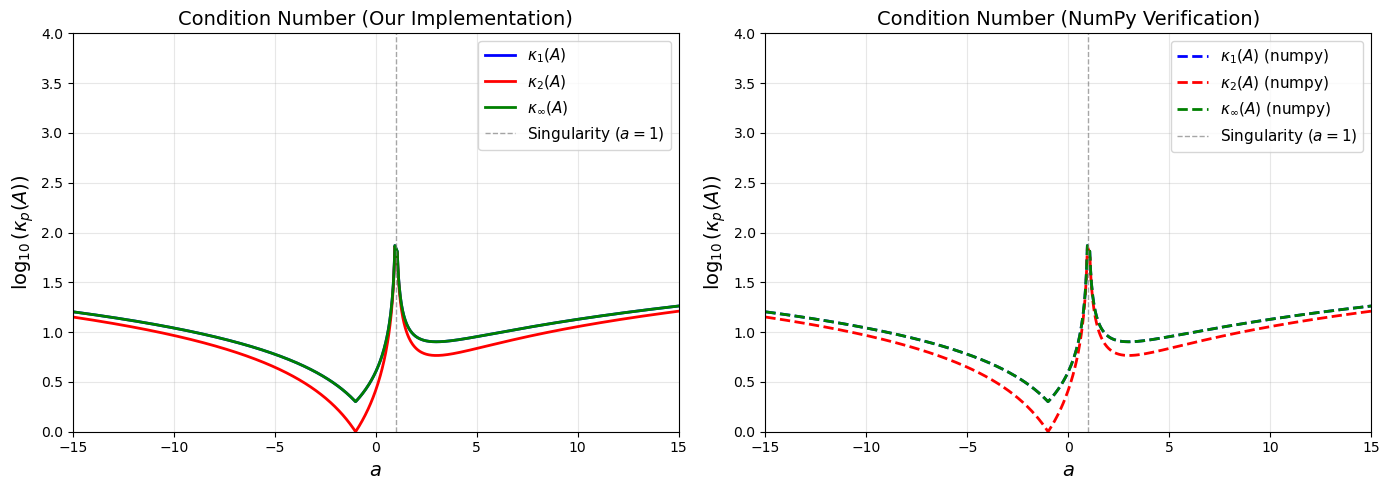

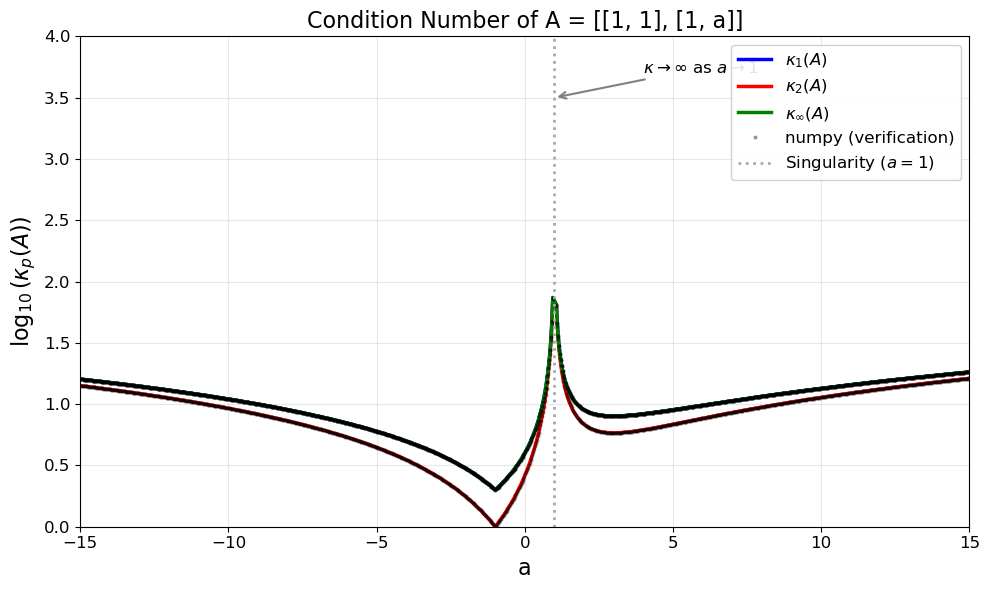

In [5]:
# Create array of a values, avoiding a=1 where matrix is singular
a_vals = numpy.linspace(-15, 15, 1000)
a_vals = a_vals[numpy.abs(a_vals - 1.0) > 0.05]  # Exclude region near singularity

# Compute condition numbers for each p-norm
kappa_1 = numpy.array([mycond(a, 1) for a in a_vals])
kappa_2 = numpy.array([mycond(a, 2) for a in a_vals])
kappa_inf = numpy.array([mycond(a, numpy.inf) for a in a_vals])

# Compute numpy's condition numbers for verification
kappa_1_np = numpy.array([numpy.linalg.cond(numpy.array([[1., 1.], [1., a]]), 1) for a in a_vals])
kappa_2_np = numpy.array([numpy.linalg.cond(numpy.array([[1., 1.], [1., a]]), 2) for a in a_vals])
kappa_inf_np = numpy.array([numpy.linalg.cond(numpy.array([[1., 1.], [1., a]]), numpy.inf) for a in a_vals])

# Create the plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Our implementation
ax1 = axes[0]
ax1.plot(a_vals, numpy.log10(kappa_1), 'b-', linewidth=2, label=r'$\kappa_1(A)$')
ax1.plot(a_vals, numpy.log10(kappa_2), 'r-', linewidth=2, label=r'$\kappa_2(A)$')
ax1.plot(a_vals, numpy.log10(kappa_inf), 'g-', linewidth=2, label=r'$\kappa_\infty(A)$')
ax1.axvline(x=1, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Singularity ($a=1$)')
ax1.set_xlabel(r'$a$', fontsize=14)
ax1.set_ylabel(r'$\log_{10}(\kappa_p(A))$', fontsize=14)
ax1.set_title('Condition Number (Our Implementation)', fontsize=14)
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([-15, 15])
ax1.set_ylim([0, 4])

# Right plot: NumPy verification
ax2 = axes[1]
ax2.plot(a_vals, numpy.log10(kappa_1_np), 'b--', linewidth=2, label=r'$\kappa_1(A)$ (numpy)')
ax2.plot(a_vals, numpy.log10(kappa_2_np), 'r--', linewidth=2, label=r'$\kappa_2(A)$ (numpy)')
ax2.plot(a_vals, numpy.log10(kappa_inf_np), 'g--', linewidth=2, label=r'$\kappa_\infty(A)$ (numpy)')
ax2.axvline(x=1, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Singularity ($a=1$)')
ax2.set_xlabel(r'$a$', fontsize=14)
ax2.set_ylabel(r'$\log_{10}(\kappa_p(A))$', fontsize=14)
ax2.set_title('Condition Number (NumPy Verification)', fontsize=14)
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([-15, 15])
ax2.set_ylim([0, 4])

plt.tight_layout()
plt.savefig('condition_number_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Single elegant plot with both implementations overlaid
fig, ax = plt.subplots(figsize=(10, 6))

# Our implementation (solid lines)
ax.plot(a_vals, numpy.log10(kappa_1), 'b-', linewidth=2.5, label=r'$\kappa_1(A)$')
ax.plot(a_vals, numpy.log10(kappa_2), 'r-', linewidth=2.5, label=r'$\kappa_2(A)$')
ax.plot(a_vals, numpy.log10(kappa_inf), 'g-', linewidth=2.5, label=r'$\kappa_\infty(A)$')

# NumPy verification (dashed lines, thinner)
ax.plot(a_vals, numpy.log10(kappa_1_np), 'ko', markersize=2, alpha=0.3, label='numpy (verification)')
ax.plot(a_vals, numpy.log10(kappa_2_np), 'ko', markersize=2, alpha=0.3)
ax.plot(a_vals, numpy.log10(kappa_inf_np), 'ko', markersize=2, alpha=0.3)

# Mark the singularity
ax.axvline(x=1, color='darkgray', linestyle=':', linewidth=2, label=r'Singularity ($a=1$)')

# Labels and formatting
ax.set_xlabel('a', fontsize=16)
ax.set_ylabel(r'$\log_{10}(\kappa_p(A))$', fontsize=16)
ax.set_title('Condition Number of A = [[1, 1], [1, a]]', fontsize=16)
ax.legend(loc='upper right', fontsize=12, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='-')
ax.set_xlim([-15, 15])
ax.set_ylim([0, 4])
ax.tick_params(axis='both', labelsize=12)

# Add annotation near singularity
ax.annotate(r'$\kappa \to \infty$ as $a \to 1$', 
            xy=(1, 3.5), xytext=(4, 3.7),
            fontsize=12, ha='left',
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

plt.tight_layout()
plt.show()

**(d)** [4] Given your plot comment on the following:
* What value of $a$ gives the best conditioned matrix.  Why?
* What value of $a$ gives the least well-condition matrix.  Why?
* Does it matter which norm we measure the condition number in?
* What value of $a$ gives the best conditioned matrix for $a>1$
 

YOUR ANSWER HERE

## Question 2: Conditioning and LU factorization

Consider the two identical linear problems $A\mathbf{x}=\bf{b}$

$$
    \begin{bmatrix} \epsilon & 1 \\ 1 & 1 \\ \end{bmatrix}\mathbf{x}=\begin{bmatrix} 1\\ 2\end{bmatrix} \quad\quad
     \begin{bmatrix} 1 & 1 \\\epsilon & 1 \\ \end{bmatrix}\mathbf{x}=\begin{bmatrix} 2\\ 1\end{bmatrix} 
$$
where $\epsilon \ll \epsilon_{mach}$

**(a)**  [6 pts] Find the 1 condition number of both matrices. Are they the same?  Are these matrices well conditioned? Check your answer using numpy with $\epsilon = 0.1\epsilon_{mach}$

YOUR ANSWER HERE

In [6]:
# Set epsilon = 0.1 * machine epsilon
eps = 0.1 * numpy.finfo(float).eps
print(f"epsilon = {eps}")
print(f"machine epsilon = {numpy.finfo(float).eps}")

# Define the two matrices
A1 = numpy.array([[eps, 1],
                  [1,   1]])

A2 = numpy.array([[1,   1],
                  [eps, 1]])

# Compute 1-norm condition numbers
cond_A1 = numpy.linalg.cond(A1, 1)
cond_A2 = numpy.linalg.cond(A2, 1)

print(f"\nCondition number (1-norm) of A1: {cond_A1}")
print(f"Condition number (1-norm) of A2: {cond_A2}")

# Verify by computing norms directly
print(f"\n||A1||_1 = {numpy.linalg.norm(A1, 1)}")
print(f"||A1^-1||_1 = {numpy.linalg.norm(numpy.linalg.inv(A1), 1)}")
print(f"\n||A2||_1 = {numpy.linalg.norm(A2, 1)}")
print(f"||A2^-1||_1 = {numpy.linalg.norm(numpy.linalg.inv(A2), 1)}")

epsilon = 2.2204460492503132e-17
machine epsilon = 2.220446049250313e-16

Condition number (1-norm) of A1: 4.0
Condition number (1-norm) of A2: 4.0

||A1||_1 = 2.0
||A1^-1||_1 = 2.0

||A2||_1 = 2.0
||A2^-1||_1 = 2.0


**(b)**  [4 pts] Find the analytic solution to both problems in infinite precision.  Are they the same?

YOUR ANSWER HERE

**(c)**  [4 pts] Now solve both problems analytically using the $LU$ decomposition *without pivoting* but applying the rules of floating point math.  Do you get the same answer?  

YOUR ANSWER HERE

**(d)**  [6 pts] Check your solutions using numpy.  

For each problem 
* Calculate the solution using $L\mathbf{c}=\mathbf{b}$, $U\mathbf{x}=\mathbf{c}$ for each pair of $L,U$ derived above (you can use numpy here with $\epsilon=0.1\epsilon_{mach}$)
* Calculate the 1-condition number for each $L$ and $U$ 

Briefly explain these results


In [7]:
eps = 0.1 * numpy.finfo(float).eps
print(f"epsilon = {eps}\n")

# ============================================
# System 1: Small pivot (epsilon in top-left)
# ============================================
print("="*50)
print("SYSTEM 1: A = [[ε, 1], [1, 1]]")
print("="*50)

# L and U from analytical derivation
L1 = numpy.array([[1.0, 0.0],
                  [1.0/eps, 1.0]])

U1 = numpy.array([[eps, 1.0],
                  [0.0, 1.0 - 1.0/eps]])

b1 = numpy.array([1.0, 2.0])

print(f"\nL1 = ")
print(L1)
print(f"\nU1 = ")
print(U1)

# Solve Lc = b (forward substitution)
c1 = numpy.linalg.solve(L1, b1)
print(f"\nSolve L1 * c = b1:")
print(f"  c = {c1}")

# Solve Ux = c (back substitution)
x1 = numpy.linalg.solve(U1, c1)
print(f"\nSolve U1 * x = c:")
print(f"  x = {x1}")

# Condition numbers
cond_L1 = numpy.linalg.cond(L1, 1)
cond_U1 = numpy.linalg.cond(U1, 1)
print(f"\nCondition numbers (1-norm):")
print(f"  κ(L1) = {cond_L1:.6e}")
print(f"  κ(U1) = {cond_U1:.6e}")

# Verify: compute residual
A1 = numpy.array([[eps, 1.0], [1.0, 1.0]])
residual1 = numpy.linalg.norm(A1 @ x1 - b1, 1)
print(f"\nResidual ||A1*x - b1||_1 = {residual1:.6e}")
print(f"Error ||x - [1,1]||_1 = {numpy.linalg.norm(x1 - [1,1], 1):.6e}")

# ============================================
# System 2: Good pivot (1 in top-left)
# ============================================
print("\n" + "="*50)
print("SYSTEM 2: A = [[1, 1], [ε, 1]]")
print("="*50)

# L and U from analytical derivation
L2 = numpy.array([[1.0, 0.0],
                  [eps, 1.0]])

U2 = numpy.array([[1.0, 1.0],
                  [0.0, 1.0 - eps]])

b2 = numpy.array([2.0, 1.0])

print(f"\nL2 = ")
print(L2)
print(f"\nU2 = ")
print(U2)

# Solve Lc = b (forward substitution)
c2 = numpy.linalg.solve(L2, b2)
print(f"\nSolve L2 * c = b2:")
print(f"  c = {c2}")

# Solve Ux = c (back substitution)
x2 = numpy.linalg.solve(U2, c2)
print(f"\nSolve U2 * x = c:")
print(f"  x = {x2}")

# Condition numbers
cond_L2 = numpy.linalg.cond(L2, 1)
cond_U2 = numpy.linalg.cond(U2, 1)
print(f"\nCondition numbers (1-norm):")
print(f"  κ(L2) = {cond_L2:.6e}")
print(f"  κ(U2) = {cond_U2:.6e}")

# Verify: compute residual
A2 = numpy.array([[1.0, 1.0], [eps, 1.0]])
residual2 = numpy.linalg.norm(A2 @ x2 - b2, 1)
print(f"\nResidual ||A2*x - b2||_1 = {residual2:.6e}")
print(f"Error ||x - [1,1]||_1 = {numpy.linalg.norm(x2 - [1,1], 1):.6e}")

epsilon = 2.2204460492503132e-17

SYSTEM 1: A = [[ε, 1], [1, 1]]

L1 = 
[[1.000000000000000e+00 0.000000000000000e+00]
 [4.503599627370496e+16 1.000000000000000e+00]]

U1 = 
[[ 2.2204460492503132e-17  1.0000000000000000e+00]
 [ 0.0000000000000000e+00 -4.5035996273704960e+16]]

Solve L1 * c = b1:
  c = [ 1.000000000000000e+00 -4.503599627370496e+16]

Solve U1 * x = c:
  x = [0. 1.]

Condition numbers (1-norm):
  κ(L1) = 2.028241e+33
  κ(U1) = 2.028241e+33

Residual ||A1*x - b1||_1 = 1.000000e+00
Error ||x - [1,1]||_1 = 1.000000e+00

SYSTEM 2: A = [[1, 1], [ε, 1]]

L2 = 
[[1.0000000000000000e+00 0.0000000000000000e+00]
 [2.2204460492503132e-17 1.0000000000000000e+00]]

U2 = 
[[1. 1.]
 [0. 1.]]

Solve L2 * c = b2:
  c = [2. 1.]

Solve U2 * x = c:
  x = [1. 1.]

Condition numbers (1-norm):
  κ(L2) = 1.000000e+00
  κ(U2) = 4.000000e+00

Residual ||A2*x - b2||_1 = 0.000000e+00
Error ||x - [1,1]||_1 = 0.000000e+00


YOUR ANSWER HERE